<a href="https://colab.research.google.com/github/davidgeraldi/Calculo-Numerico-UNIFESP/blob/main/Atividade_4_Sistemas_Lineares_Gauss_LU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sistemas de equações lineares: métodos diretos até a decomposição LU


**Objetivo geral:** compreender e aplicar, passo a passo, a eliminação de Gauss e a fatoração LU para resolver sistemas lineares.



## 1. O problema e sua interpretação

Um sistema com $n$ equações e $n$ incógnitas pode ser escrito como

$$A\mathbf{x}=\mathbf{b},$$

onde $A$ é a matriz dos coeficientes, $\mathbf{x}$ é o vetor das incógnitas e $\mathbf{b}$ reúne os termos independentes.

### Exemplo de motivação: balanço térmico

Em uma rede térmica simplificada, as temperaturas nodais desconhecidas podem satisfazer

$$\begin{aligned}4T_1-T_2&=100,\\-T_1+4T_2-T_3&=100,\\-T_2+3T_3&=50.\end{aligned}$$

Os coeficientes representam os acoplamentos entre nós e as condições impostas. A mesma estrutura matemática aparece em redes elétricas, estruturas, circuitos hidráulicos, difusão e discretizações numéricas de equações diferenciais.

In [2]:
import numpy as np
np.set_printoptions(precision=6, suppress=True)

A = np.array([[4., -1.,  0.],
              [-1., 4., -1.],
              [0., -1., 3.]])
b = np.array([100., 100., 50.])

print("Matriz A:\n", A)
print("Vetor b:", b)

Matriz A:
 [[ 4. -1.  0.]
 [-1.  4. -1.]
 [ 0. -1.  3.]]
Vetor b: [100. 100.  50.]


##2. Operações elementares nas equações

A eliminação de Gauss transforma o sistema em outro equivalente, isto é, em um sistema que possui o mesmo conjunto de soluções. Para isso, aplicamos operações elementares às equações:
1. Permutar duas equações — trocar a posição de duas linhas.
2. Multiplicar uma equação por uma constante não nula — multiplicar todos os seus termos pelo mesmo valor.
3. Somar a uma equação um múltiplo de outra — substituir uma equação pela soma dela com um múltiplo de outra equação.
Na forma matricial, essas operações são realizadas nas linhas da matriz aumentada,
\[
[A\mid\mathbf{b}],
\]
que reúne a matriz dos coeficientes \(A\) e o vetor dos termos independentes \(\mathbf{b}\).
O objetivo é usar os pivôs para eliminar, coluna por coluna, os coeficientes abaixo deles. Ao final, obtemos um sistema triangular superior, que pode ser resolvido de baixo para cima por substituição regressiva.

In [3]:
M = np.column_stack([A, b])
print("Matriz aumentada [A | b]:\n", M)

Matriz aumentada [A | b]:
 [[  4.  -1.   0. 100.]
 [ -1.   4.  -1. 100.]
 [  0.  -1.   3.  50.]]


SyntaxError: invalid syntax (1473950665.py, line 3)

## 3. Eliminação de Gauss: exemplo calculado à mão

Considere o sistema:

$$
\begin{aligned}
2x+y-z&=8,\\
-3x-y+2z&=-11,\\
-2x+y+2z&=-3.
\end{aligned}
$$

Cada linha representa uma equação. Podemos organizar os coeficientes das incógnitas e os termos independentes na matriz aumentada:

$$
\left[
\begin{array}{rrr|r}
2&1&-1&8\\
-3&-1&2&-11\\
-2&1&2&-3
\end{array}
\right].
$$

A barra vertical separa os coeficientes das incógnitas dos termos independentes. Na eliminação de Gauss, fazemos operações nas linhas para criar zeros abaixo dos **pivôs**. Um pivô é o elemento da diagonal que usamos para eliminar outros elementos da mesma coluna.

### Passo 1 — Eliminar os elementos abaixo do primeiro pivô



A matriz aumentada inicial é:

$$
\left[
\begin{array}{rrr|r}
2&1&-1&8\\
-3&-1&2&-11\\
-2&1&2&-3
\end{array}
\right].
$$

O **primeiro pivô** é o elemento $a_{11}=2$, que está na primeira linha e primeira coluna. Vamos usá-lo para zerar os elementos que aparecem abaixo dele na mesma coluna: $-3$ e $-2$.

Para cada elemento que queremos eliminar, calculamos um multiplicador dividindo esse elemento pelo pivô:

$$
m_{21}=\frac{a_{21}}{a_{11}}=\frac{-3}{2}=-\frac{3}{2},
\qquad
m_{31}=\frac{a_{31}}{a_{11}}=\frac{-2}{2}=-1.
$$

O multiplicador nos diz quanto da primeira linha deve ser usado para modificar a linha correspondente. A regra geral é:

$$
R_i\leftarrow R_i-m_{i1}R_1.
$$

Para a segunda linha, como $m_{21}=-\frac{3}{2}$, subtrair esse múltiplo equivale a somar $\frac{3}{2}$ da primeira linha:

$$
R_2\leftarrow R_2-m_{21}R_1
=R_2+\frac{3}{2}R_1.
$$

Fazemos a operação em todos os elementos da linha, incluindo o termo independente:

$$
\begin{aligned}
R_2
&=[-3,-1,2\mid -11]
+\frac{3}{2}[2,1,-1\mid 8]\\
&=[-3,-1,2\mid -11]
+[3,\tfrac{3}{2},-\tfrac{3}{2}\mid 12]\\
&=[0,\tfrac{1}{2},\tfrac{1}{2}\mid 1].
\end{aligned}
$$

O primeiro elemento da nova linha é zero porque $-3+\frac{3}{2}(2)=-3+3=0$.

Para a terceira linha, $m_{31}=-1$. Portanto:

$$
R_3\leftarrow R_3-m_{31}R_1
=R_3+R_1.
$$

Assim:

$$
\begin{aligned}
R_3
&=[-2,1,2\mid -3]+[2,1,-1\mid 8]\\
&=[0,2,1\mid 5].
\end{aligned}
$$

O primeiro elemento também se tornou zero: $-2+2=0$. Após as duas operações, a matriz aumentada é:

$$
\left[
\begin{array}{rrr|r}
2&1&-1&8\\
0&\tfrac{1}{2}&\tfrac{1}{2}&1\\
0&2&1&5
\end{array}
\right].
$$

Eliminamos, assim, a incógnita $x$ das equações 2 e 3. A primeira coluna abaixo do pivô agora contém zeros.

### Passo 2 — Eliminar o elemento abaixo do segundo pivô

O **segundo pivô** é $a_{22}=\frac{1}{2}$, na segunda linha e segunda coluna. Abaixo dele está o elemento $2$, na terceira linha. Queremos transformar esse $2$ em zero.

Calculamos o multiplicador dividindo o elemento a eliminar pelo pivô:

$$
m_{32}=\frac{a_{32}}{a_{22}}
=\frac{2}{\frac{1}{2}}=4.
$$

Isso significa que devemos subtrair quatro vezes a segunda linha da terceira:

$$
R_3\leftarrow R_3-4R_2.
$$

Primeiro, calculamos quatro vezes a segunda linha:

$$
4R_2
=4[0,\tfrac{1}{2},\tfrac{1}{2}\mid 1]
=[0,2,2\mid 4].
$$

Depois, subtraímos esse resultado da terceira linha:

$$
\begin{aligned}
R_3
&=[0,2,1\mid 5]-[0,2,2\mid 4]\\
&=[0,0,-1\mid 1].
\end{aligned}
$$

O elemento da segunda coluna tornou-se zero porque $2-4(\frac{1}{2})=2-2=0$. A matriz aumentada resultante é:

$$
\left[
\begin{array}{rrr|r}
2&1&-1&8\\
0&\tfrac{1}{2}&\tfrac{1}{2}&1\\
0&0&-1&1
\end{array}
\right].
$$

Agora todos os elementos abaixo da diagonal principal são zero. Por isso, a matriz está na forma **triangular superior**. O sistema equivalente é:

$$
\begin{aligned}
2x+y-z&=8,\\
\frac{1}{2}y+\frac{1}{2}z&=1,\\
-z&=1.
\end{aligned}
$$

Podemos resolver esse sistema de baixo para cima: primeiro encontramos $z$ na última equação, depois usamos esse resultado para calcular $y$ e, por fim, encontramos $x$. Esse procedimento é chamado de **substituição regressiva**.

Na célula seguinte, implemente em Python as operações de linha e compare a matriz calculada pelo código com a matriz triangular superior obtida manualmente.

In [4]:
A_g = np.array([[2.,1.,-1.],[-3.,-1.,2.],[-2.,1.,2.]])
b_g = np.array([8.,-11.,-3.])
M_g = np.column_stack((A_g,b_g))
print("Inicial:\n",M_g)

# Passo 1: eliminar a primeira coluna abaixo do pivô
m21 = M_g[1,0]/M_g[0,0]
m31 = M_g[2,0]/M_g[0,0]
M_g[1,:] -= m21*M_g[0,:]
M_g[2,:] -= m31*M_g[0,:]
print("Após eliminar abaixo do pivô 1; multiplicadores:",m21,m31,"\n",M_g)

# Passo 2: eliminar a segunda coluna abaixo do pivô
m32 = M_g[2,1]/M_g[1,1]
M_g[2,:] -= m32*M_g[1,:]
print("Após eliminar abaixo do pivô 2; multiplicador:",m32,"\n",M_g)

Inicial:
 [[  2.   1.  -1.   8.]
 [ -3.  -1.   2. -11.]
 [ -2.   1.   2.  -3.]]
Após eliminar abaixo do pivô 1; multiplicadores: -1.5 -1.0 
 [[ 2.   1.  -1.   8. ]
 [ 0.   0.5  0.5  1. ]
 [ 0.   2.   1.   5. ]]
Após eliminar abaixo do pivô 2; multiplicador: 4.0 
 [[ 2.   1.  -1.   8. ]
 [ 0.   0.5  0.5  1. ]
 [ 0.   0.  -1.   1. ]]


### 3.1 Substituição regressiva

Depois da eliminação de Gauss, o sistema fica na forma triangular superior. Isso significa que a última equação contém apenas a última incógnita; a penúltima equação contém as duas últimas incógnitas; e assim por diante.

Para três incógnitas, podemos escrever o sistema na forma:

$$
\begin{aligned}
u_{11}x_1+u_{12}x_2+u_{13}x_3&=c_1,\\
u_{22}x_2+u_{23}x_3&=c_2,\\
u_{33}x_3&=c_3.
\end{aligned}
$$

Começamos pela última equação, que contém apenas $x_3$. Isolando essa incógnita, temos:

$$
u_{33}x_3=c_3
\quad\Longrightarrow\quad
x_3=\frac{c_3}{u_{33}}.
$$

Depois, substituímos o valor de $x_3$ na segunda equação e calculamos $x_2$:

$$
u_{22}x_2+u_{23}x_3=c_2
\quad\Longrightarrow\quad
x_2=\frac{c_2-u_{23}x_3}{u_{22}}.
$$

Por fim, substituímos os valores de $x_2$ e $x_3$ na primeira equação para calcular $x_1$:

$$
u_{11}x_1+u_{12}x_2+u_{13}x_3=c_1
\quad\Longrightarrow\quad
x_1=\frac{c_1-u_{12}x_2-u_{13}x_3}{u_{11}}.
$$

Esse procedimento é chamado de **substituição regressiva** porque resolvemos as equações de baixo para cima. Em cada etapa, usamos os valores já calculados para encontrar a próxima incógnita.

Aplicando o método ao sistema triangular obtido no exemplo:

$$
\begin{aligned}
2x+y-z&=8,\\
\frac12y+\frac12z&=1,\\
-z&=1,
\end{aligned}
$$

começamos pela última equação:

$$
-z=1
\quad\Longrightarrow\quad
z=-1.
$$

Substituímos $z=-1$ na segunda equação:

$$
\frac12y+\frac12(-1)=1
\quad\Longrightarrow\quad
\frac12y-\frac12=1
\quad\Longrightarrow\quad
y=3.
$$

Agora, substituímos $y=3$ e $z=-1$ na primeira equação:

$$
2x+3-(-1)=8
\quad\Longrightarrow\quad
2x+4=8
\quad\Longrightarrow\quad
x=2.
$$

Portanto, a solução é:

$$
\boxed{x=2,\qquad y=3,\qquad z=-1.}
$$

Para verificar o resultado, substituímos os valores nas equações originais:

$$
\begin{aligned}
2(2)+3-(-1)&=8,\\
-3(2)-3+2(-1)&=-11,\\
-2(2)+3+2(-1)&=-3.
\end{aligned}
$$

As três igualdades são satisfeitas. Assim, confirmamos que a solução está correta.

> **Observação:** os elementos da diagonal principal, chamados de pivôs, precisam ser diferentes de zero para que as divisões da substituição regressiva possam ser realizadas.

In [5]:
U_g = M_g[:,:-1]
c_g = M_g[:,-1]
x_g = np.zeros(3)
for i in range(2,-1,-1):
    x_g[i] = (c_g[i] - U_g[i,i+1:] @ x_g[i+1:]) / U_g[i,i]
print("Solução por eliminação e substituição regressiva:",x_g)
print("Conferência A x - b:",A_g@x_g-b_g)

Solução por eliminação e substituição regressiva: [ 2.  3. -1.]
Conferência A x - b: [0. 0. 0.]


### Funções didáticas para eliminação e substituição

A implementação abaixo mostra os mesmos passos em um algoritmo geral. A matriz é copiada para que os dados originais permaneçam disponíveis.

In [6]:
def substituicao_regressiva(U, c):
    """Resolve Ux=c, onde U é triangular superior."""
    U = np.asarray(U, dtype=float)
    c = np.asarray(c, dtype=float)
    n = len(c)
    x = np.zeros(n)
    for i in range(n-1, -1, -1):
        if abs(U[i,i]) < 1e-14:
            raise np.linalg.LinAlgError("Pivô nulo na substituição regressiva")
        x[i] = (c[i] - U[i,i+1:] @ x[i+1:]) / U[i,i]
    return x

def eliminacao_gauss_sem_pivoteamento(A, b):
    """Eliminação de Gauss didática; requer pivôs não nulos."""
    U = np.array(A, dtype=float, copy=True)
    c = np.array(b, dtype=float, copy=True)
    n = len(c)
    for k in range(n-1):
        if abs(U[k,k]) < 1e-14:
            raise np.linalg.LinAlgError("Pivô zero: é necessária uma troca de linhas")
        for i in range(k+1,n):
            fator = U[i,k]/U[k,k]
            U[i,k:] -= fator*U[k,k:]
            c[i] -= fator*c[k]
    return substituicao_regressiva(U,c), U, c

x0, U0, c0 = eliminacao_gauss_sem_pivoteamento(A_g,b_g)
print("U =\n",U0)
print("c transformado =",c0)
print("x =",x0)

U =
 [[ 2.   1.  -1. ]
 [ 0.   0.5  0.5]
 [ 0.   0.  -1. ]]
c transformado = [8. 1. 1.]
x = [ 2.  3. -1.]


## 4. Pivoteamento parcial

Na eliminação de Gauss, cada etapa usa um elemento chamado **pivô** para eliminar os coeficientes que estão abaixo dele. Em princípio, podemos seguir as operações diretamente. Porém, há situações em que o pivô escolhido não permite realizar a divisão ou pode levar a resultados numericamente pouco confiáveis.

- Se o pivô for **zero**, não podemos dividir por ele. A eliminação precisa parar nessa etapa.
- Se o pivô for **muito pequeno**, as divisões podem produzir multiplicadores muito grandes. Em cálculos com precisão finita, isso pode amplificar os erros de arredondamento.

O **pivoteamento parcial** reduz esse problema. Em cada coluna $k$, comparamos os valores absolutos dos elementos desde a linha $k$ até a última linha. Escolhemos o maior deles e trocamos sua linha com a linha $k$. O elemento selecionado passa a ser o pivô da etapa.

Em outras palavras, a cada etapa:

1. observamos a coluna que está sendo eliminada;
2. procuramos, entre a linha atual e as linhas abaixo dela, o elemento de maior módulo;
3. trocamos as linhas para colocar esse elemento na posição do pivô;
4. continuamos a eliminação de Gauss.

Usamos o módulo porque queremos comparar o tamanho dos elementos sem considerar se são positivos ou negativos. Por exemplo, entre $-7$ e $4$, o elemento de maior módulo é $-7$, pois $|-7|=7$ e $|4|=4$.

### Exemplo: pivô nulo

Considere o sistema:

$$
\begin{aligned}
0x+2y&=4,\\
x+y&=3.
\end{aligned}
$$

A matriz aumentada é:

$$
\left[
\begin{array}{rr|r}
0&2&4\\
1&1&3
\end{array}
\right].
$$

O primeiro elemento da primeira coluna seria o pivô inicial. Como esse elemento é zero, não podemos usá-lo para eliminar o elemento abaixo dele: isso exigiria uma divisão por zero.

Na primeira coluna, comparamos os elementos disponíveis nas linhas 1 e 2. Em módulo, eles são:

$$
|0|=0,
\qquad
|1|=1.
$$

O maior módulo é $1$, que está na segunda linha. Trocamos as duas linhas:

$$
R_1\leftrightarrow R_2.
$$

A matriz aumentada passa a ser:

$$
\left[
\begin{array}{rr|r}
1&1&3\\
0&2&4
\end{array}
\right].
$$

Agora o primeiro pivô é $1$, então podemos continuar a eliminação sem dividir por zero. Nesse exemplo, o elemento abaixo do pivô já é zero, e a matriz já está triangular superior. O sistema correspondente é:

$$
\begin{aligned}
x+y&=3,\\
2y&=4.
\end{aligned}
$$

A troca de linhas não altera o conjunto de soluções: apenas muda a ordem das equações. Por substituição regressiva, obtemos $y=2$ e, em seguida, $x=1$.

> **Ideia principal:** no pivoteamento parcial, escolhemos como pivô o maior elemento, em módulo, disponível na coluna atual. Isso evita pivôs nulos e ajuda a reduzir a amplificação dos erros de arredondamento.

In [7]:
A_p = np.array([[0.,2.],[1.,1.]])
b_p = np.array([4.,3.])
print("Sem troca, primeiro pivô:",A_p[0,0])
print("Solução de referência:",np.linalg.solve(A_p,b_p))

Sem troca, primeiro pivô: 0.0
Solução de referência: [1. 2.]


### Algoritmo de Gauss com pivoteamento parcial, comentado

Em cada coluna, `argmax(abs(U[k:, k]))` localiza o maior candidato a pivô. A troca precisa ser aplicada tanto à matriz quanto ao vetor do lado direito.

In [8]:
def gauss_pivoteamento_parcial(A, b, tol=1e-12):
    """Resolve Ax=b por Gauss com pivoteamento parcial e retorna detalhes."""
    U = np.array(A, dtype=float, copy=True)
    c = np.array(b, dtype=float, copy=True)
    n = len(c)
    if U.shape != (n,n):
        raise ValueError("A precisa ser quadrada e compatível com b")
    trocas = []
    for k in range(n-1):
        # Escolhe o maior pivô em módulo na parte ainda não eliminada
        p = k + np.argmax(np.abs(U[k:,k]))
        if abs(U[p,k]) < tol:
            raise np.linalg.LinAlgError("Matriz singular ou pivô muito pequeno")
        if p != k:
            U[[k,p],:] = U[[p,k],:]
            c[[k,p]] = c[[p,k]]
            trocas.append((k,p))
        # Elimina os elementos abaixo do pivô escolhido
        for i in range(k+1,n):
            fator = U[i,k]/U[k,k]
            U[i,k:] -= fator*U[k,k:]
            c[i] -= fator*c[k]
    if abs(U[-1,-1]) < tol:
        raise np.linalg.LinAlgError("Matriz singular ou último pivô muito pequeno")
    x = substituicao_regressiva(U,c)
    return x,U,c,trocas

xp, Up, cp, trocas = gauss_pivoteamento_parcial(A_p,b_p)
print("Matriz triangular superior:\n",Up)
print("Lado direito transformado:",cp)
print("Trocas de linhas (índices começando em zero):",trocas)
print("Solução:",xp)
print("Resíduo:",np.linalg.norm(A_p@xp-b_p))

Matriz triangular superior:
 [[1. 1.]
 [0. 2.]]
Lado direito transformado: [3. 4.]
Trocas de linhas (índices começando em zero): [(0, np.int64(1))]
Solução: [1. 2.]
Resíduo: 0.0


## 5. Resíduo: conferir a solução calculada

O resíduo é $\mathbf{r}=\mathbf{b}-A\widehat{\mathbf{x}}$. Ele mede o quanto a solução aproximada satisfaz as equações originais. Um resíduo pequeno é necessário para uma boa solução, mas, em sistemas mal condicionados, não garante por si só que o erro em $\widehat{\mathbf{x}}$ seja pequeno.

Compare a solução calculada com a solução de uma biblioteca numérica. A biblioteca serve aqui como conferência, não como substituto da compreensão do algoritmo.

In [9]:
x_num, U_num, c_num, swaps = gauss_pivoteamento_parcial(A,b)
x_numpy = np.linalg.solve(A,b)
r = b-A@x_num
print("Solução manual/algoritmo:",x_num)
print("Solução NumPy:",x_numpy)
print("Erro entre soluções:",np.linalg.norm(x_num-x_numpy))
print("Resíduo:",r)
print("Norma do resíduo:",np.linalg.norm(r))

Solução manual/algoritmo: [35.365854 41.463415 30.487805]
Solução NumPy: [35.365854 41.463415 30.487805]
Erro entre soluções: 0.0
Resíduo: [ 0.  0. -0.]
Norma do resíduo: 7.105427357601002e-15


## 6. Decomposição LU: ideia

A fatoração LU escreve a matriz como produto de duas matrizes triangulares:

$$A=LU,$$

onde $L$ é triangular inferior e $U$ é triangular superior. Adotaremos a convenção de **Doolittle**, na qual a diagonal de $L$ contém uns.

Para resolver $A\mathbf{x}=\mathbf{b}$:

1. fatoramos $A=LU$;
2. resolvemos $L\mathbf{y}=\mathbf{b}$ por substituição progressiva;
3. resolvemos $U\mathbf{x}=\mathbf{y}$ por substituição regressiva.

Se precisarmos resolver muitos sistemas com a mesma matriz $A$ e diferentes vetores $\mathbf{b}$, calculamos $L$ e $U$ uma única vez.

## 7. Fatoração LU de Doolittle: desenvolvimento passo a passo

Use a matriz

$$A=\begin{bmatrix}2&-1&1\\4&1&-1\\-2&2&3\end{bmatrix}.$$

Queremos encontrar

$$L=\begin{bmatrix}1&0&0\\l_{21}&1&0\\l_{31}&l_{32}&1\end{bmatrix},\qquad U=\begin{bmatrix}u_{11}&u_{12}&u_{13}\\0&u_{22}&u_{23}\\0&0&u_{33}\end{bmatrix}$$

tal que $LU=A$. Igualamos as entradas de $LU$ às entradas de $A$, coluna por coluna.

### Passo 1 — primeira linha de U

Como a primeira linha de $L$ é $[1,0,0]$, a primeira linha de $LU$ coincide com a primeira linha de $U$. Portanto

$$u_{11}=2,\qquad u_{12}=-1,\qquad u_{13}=1.$$

### Passo 2 — primeira coluna de L

A entrada $(2,1)$ do produto é $l_{21}u_{11}=4$, então $l_{21}=4/2=2$.

A entrada $(3,1)$ é $l_{31}u_{11}=-2$, então $l_{31}=-2/2=-1$.

### Passo 3 — entradas restantes da segunda linha de U

A entrada $(2,2)$ do produto é $l_{21}u_{12}+u_{22}=1$. Assim

$$u_{22}=1-(2)(-1)=3.$$

A entrada $(2,3)$ é $l_{21}u_{13}+u_{23}=-1$. Portanto

$$u_{23}=-1-(2)(1)=-3.$$

### Passo 4 — elemento $l_{32}$

Na entrada $(3,2)$:

$$l_{31}u_{12}+l_{32}u_{22}=2.$$

Substituindo os valores conhecidos, $(-1)(-1)+3l_{32}=2$, de modo que $l_{32}=1/3$.

### Passo 5 — último elemento $u_{33}$

Na entrada $(3,3)$:

$$l_{31}u_{13}+l_{32}u_{23}+u_{33}=3.$$

Logo, $(-1)(1)+(1/3)(-3)+u_{33}=3$, e portanto $u_{33}=5$.

Concluímos que

$$L=\begin{bmatrix}1&0&0\\2&1&0\\-1&1/3&1\end{bmatrix},\qquad U=\begin{bmatrix}2&-1&1\\0&3&-3\\0&0&5\end{bmatrix}.$$

In [10]:
A_lu = np.array([[2.,-1.,1.],[4.,1.,-1.],[-2.,2.,3.]])
L = np.array([[1.,0.,0.],[2.,1.,0.],[-1.,1/3,1.]])
U = np.array([[2.,-1.,1.],[0.,3.,-3.],[0.,0.,5.]])
print("L =\n",L)
print("U =\n",U)
print("LU =\n",L@U)
print("A =\n",A_lu)
print("||A-LU|| =",np.linalg.norm(A_lu-L@U))

L =
 [[ 1.        0.        0.      ]
 [ 2.        1.        0.      ]
 [-1.        0.333333  1.      ]]
U =
 [[ 2. -1.  1.]
 [ 0.  3. -3.]
 [ 0.  0.  5.]]
LU =
 [[ 2. -1.  1.]
 [ 4.  1. -1.]
 [-2.  2.  3.]]
A =
 [[ 2. -1.  1.]
 [ 4.  1. -1.]
 [-2.  2.  3.]]
||A-LU|| = 0.0


## 8. Resolver um sistema usando LU, etapa por etapa

Considere agora $A\mathbf{x}=\mathbf{b}$ com a matriz anterior e $\mathbf{b}=[2,8,-3]^T$. Primeiro resolvemos $L\mathbf{y}=\mathbf{b}$ por substituição progressiva:

$$\begin{aligned}y_1&=2,\\2y_1+y_2&=8,\\-y_1+\frac13y_2+y_3&=-3.\end{aligned}$$

Depois usamos o vetor $\mathbf{y}$ e resolvemos $U\mathbf{x}=\mathbf{y}$ por substituição regressiva. Complete os valores e confira o resíduo.

In [11]:
def substituicao_progressiva(L,b):
    """Resolve Ly=b, com L triangular inferior."""
    L = np.asarray(L,dtype=float); b=np.asarray(b,dtype=float)
    n=len(b); y=np.zeros(n)
    for i in range(n):
        if abs(L[i,i]) < 1e-14: raise np.linalg.LinAlgError("Diagonal nula em L")
        y[i]=(b[i]-L[i,:i]@y[:i])/L[i,i]
    return y

b_lu = np.array([2.,8.,-3.])
y = substituicao_progressiva(L,b_lu)
x_lu = substituicao_regressiva(U,y)
print("y, solução de Ly=b:",y)
print("x, solução de Ux=y:",x_lu)
print("Conferência NumPy:",np.linalg.solve(A_lu,b_lu))
print("Resíduo na equação original:",b_lu-A_lu@x_lu)

y, solução de Ly=b: [ 2.        4.       -2.333333]
x, solução de Ux=y: [ 1.666667  0.866667 -0.466667]
Conferência NumPy: [ 1.666667  0.866667 -0.466667]
Resíduo na equação original: [ 0.  0. -0.]


## 9. Algoritmo LU de Doolittle

A rotina abaixo constrói $L$ e $U$ usando as relações de Doolittle. Para uma matriz genérica, a fatoração sem pivoteamento pode falhar se surgir um pivô nulo. Sistemas que exigem robustez normalmente usam pivoteamento, isto é, $PA=LU$. Aqui, o objetivo é acompanhar a fatoração básica.

In [12]:
def doolittle_sem_pivoteamento(A, tol=1e-12):
    """Calcula A=LU com diag(L)=1; apropriado para demonstração."""
    A=np.asarray(A,dtype=float)
    n=A.shape[0]
    if A.shape != (n,n): raise ValueError("A deve ser quadrada")
    L=np.eye(n); U=np.zeros_like(A)
    for k in range(n):
        # Calcula a linha k de U, usando valores de L e U já conhecidos
        for j in range(k,n):
            U[k,j]=A[k,j]-L[k,:k]@U[:k,j]
        if abs(U[k,k]) < tol:
            raise np.linalg.LinAlgError("Pivô nulo; pode ser necessário pivotear")
        # Calcula a coluna k de L abaixo da diagonal
        for i in range(k+1,n):
            L[i,k]=(A[i,k]-L[i,:k]@U[:k,k])/U[k,k]
    return L,U

L_calc,U_calc=doolittle_sem_pivoteamento(A_lu)
print("L calculada:\n",L_calc)
print("U calculada:\n",U_calc)
print("Erro de reconstrução:",np.linalg.norm(A_lu-L_calc@U_calc))

L calculada:
 [[ 1.        0.        0.      ]
 [ 2.        1.        0.      ]
 [-1.        0.333333  1.      ]]
U calculada:
 [[ 2. -1.  1.]
 [ 0.  3. -3.]
 [ 0.  0.  5.]]
Erro de reconstrução: 0.0


## 11. Quando escolher Gauss ou LU?

- **Eliminação de Gauss:** caminho direto quando se quer resolver um sistema, acompanhando a redução a forma triangular.
- **LU:** conveniente quando a matriz $A$ é a mesma em vários sistemas com vetores $b$ diferentes. Faz-se a fatoração uma vez e, para cada novo $b$, executam-se duas substituições.
- **Pivoteamento:** importante para evitar pivôs nulos ou muito pequenos. A fatoração prática frequentemente é $PA=LU$, com $P$ representando as trocas de linhas.

A implementação didática ajuda a compreender as operações. Para aplicações de produção, use rotinas numéricas consolidadas e verifique resíduos, escalas e hipóteses físicas.

## 12. Geração de GIFs para visualização das iterações

Para visualizar o processo passo a passo da eliminação de Gauss e da decomposição LU, criaremos GIFs animados. Primeiro, instalaremos a biblioteca `imageio` e, em seguida, definiremos funções auxiliares para capturar e plotar os estados intermediários das matrizes.

In [13]:
# Instala a biblioteca imageio, se ainda não estiver instalada
%pip install imageio matplotlib

In [17]:
import matplotlib.pyplot as plt
import imageio
import os

def plot_matrix_state(matrix, title, filename, show_grid=False):
    """Plota uma matriz e salva a imagem com dimensões consistentes."""
    # Aumentar figsize para melhor visualização de 3x3 e 2x2, definir dpi
    fig, ax = plt.subplots(figsize=(8, 8), dpi=100)
    cax = ax.matshow(matrix, cmap='viridis')
    fig.colorbar(cax)

    # Adiciona valores da matriz na visualização
    for (i, j), val in np.ndenumerate(matrix):
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color='white', fontsize=10)

    ax.set_title(title)
    ax.set_xticks(np.arange(matrix.shape[1]))
    ax.set_yticks(np.arange(matrix.shape[0]))
    ax.set_xticklabels(np.arange(matrix.shape[1]))
    ax.set_yticklabels(np.arange(matrix.shape[0]))

    if show_grid:
        ax.set_xticks(np.arange(-0.5, matrix.shape[1], 1), minor=True)
        ax.set_yticks(np.arange(-0.5, matrix.shape[0], 1), minor=True)
        ax.grid(which='minor', color='black', linestyle='-', linewidth=2)

    # Usar tight_layout para ajustar os parâmetros do plot para um layout apertado
    # E salvar a figura sem bbox_inches='tight' ou pad_inches para garantir dimensões fixas.
    fig.tight_layout()
    plt.savefig(filename, dpi=100) # Removido bbox_inches='tight' e pad_inches
    plt.close(fig)

def create_gif(image_filenames, gif_filename, duration=0.8):
    """Cria um GIF a partir de uma lista de imagens."""
    images = []
    for filename in image_filenames:
        images.append(imageio.v2.imread(filename))
    imageio.v2.mimsave(gif_filename, images, duration=duration, loop=0)
    for filename in image_filenames: # Limpa os arquivos de imagem temporários
        os.remove(filename)
    print(f'GIF salvo como {gif_filename}')

In [18]:
# Re-executando a célula de Eliminação de Gauss para gerar o GIF
print("Re-Gerando GIF para Eliminação de Gauss...")
U_gauss_gif, c_gauss_gif = eliminacao_gauss_com_gif(A_g, b_g, gif_name='gauss_A_g.gif')
print("U final (Gauss):\n", U_gauss_gif)
print("c final (Gauss):", c_gauss_gif)

print("\nRe-Gerando GIF para Eliminação de Gauss (Problema inicial)...")
A_initial = np.array([[4., -1.,  0.],
                      [-1.,  4., -1.],
                      [0., -1.,  3.]])
b_initial = np.array([100., 100., 50.])

U_initial_gif, c_initial_gif = eliminacao_gauss_com_gif(A_initial, b_initial, gif_name='gauss_A_initial.gif')
print("U final (Problema inicial):\n", U_initial_gif)
print("c final (Problema inicial):", c_initial_gif)

# Re-executando a célula de Decomposição LU para gerar o GIF
print("\nRe-Gerando GIF para Decomposição LU...")
L_lu_gif, U_lu_gif = doolittle_com_gif(A_lu, gif_name='lu_A_lu.gif')
print("L final (LU):\n", L_lu_gif)
print("U final (LU):\n", U_lu_gif)

print("\nRe-Gerando GIF para Decomposição LU (nova matriz 2x2)...")
A_new_2x2 = np.array([[3., 1.],
                        [6., 4.]])
L_new_2x2_gif, U_new_2x2_gif = doolittle_com_gif(A_new_2x2, gif_name='lu_A_new_2x2.gif')
print("L final (Nova 2x2):\n", L_new_2x2_gif)
print("U final (Nova 2x2):\n", U_new_2x2_gif)

Re-Gerando GIF para Eliminação de Gauss...
GIF salvo como gauss_A_g.gif
U final (Gauss):
 [[ 2.   1.  -1. ]
 [ 0.   0.5  0.5]
 [ 0.   0.  -1. ]]
c final (Gauss): [8. 1. 1.]

Re-Gerando GIF para Eliminação de Gauss (Problema inicial)...
GIF salvo como gauss_A_initial.gif
U final (Problema inicial):
 [[ 4.       -1.        0.      ]
 [ 0.        3.75     -1.      ]
 [ 0.        0.        2.733333]]
c final (Problema inicial): [100.       125.        83.333333]

Re-Gerando GIF para Decomposição LU...
GIF salvo como lu_A_lu.gif
L final (LU):
 [[ 1.        0.        0.      ]
 [ 2.        1.        0.      ]
 [-1.        0.333333  1.      ]]
U final (LU):
 [[ 2. -1.  1.]
 [ 0.  3. -3.]
 [ 0.  0.  5.]]

Re-Gerando GIF para Decomposição LU (nova matriz 2x2)...
GIF salvo como lu_A_new_2x2.gif
L final (Nova 2x2):
 [[1. 0.]
 [2. 1.]]
U final (Nova 2x2):
 [[3. 1.]
 [0. 2.]]


In [19]:
# Re-executando a célula de Eliminação de Gauss para gerar o GIF
print("Re-Gerando GIF para Eliminação de Gauss...")
U_gauss_gif, c_gauss_gif = eliminacao_gauss_com_gif(A_g, b_g, gif_name='gauss_A_g.gif')
print("U final (Gauss):\n", U_gauss_gif)
print("c final (Gauss):", c_gauss_gif)

print("\nRe-Gerando GIF para Eliminação de Gauss (Problema inicial)...")
A_initial = np.array([[4., -1.,  0.],
                      [-1.,  4., -1.],
                      [0., -1.,  3.]])
b_initial = np.array([100., 100., 50.])

U_initial_gif, c_initial_gif = eliminacao_gauss_com_gif(A_initial, b_initial, gif_name='gauss_A_initial.gif')
print("U final (Problema inicial):\n", U_initial_gif)
print("c final (Problema inicial):", c_initial_gif)

# Re-executando a célula de Decomposição LU para gerar o GIF
print("\nRe-Gerando GIF para Decomposição LU...")
L_lu_gif, U_lu_gif = doolittle_com_gif(A_lu, gif_name='lu_A_lu.gif')
print("L final (LU):\n", L_lu_gif)
print("U final (LU):\n", U_lu_gif)

print("\nRe-Gerando GIF para Decomposição LU (nova matriz 2x2)...")
A_new_2x2 = np.array([[3., 1.],
                        [6., 4.]])
L_new_2x2_gif, U_new_2x2_gif = doolittle_com_gif(A_new_2x2, gif_name='lu_A_new_2x2.gif')
print("L final (Nova 2x2):\n", L_new_2x2_gif)
print("U final (Nova 2x2):\n", U_new_2x2_gif)

Re-Gerando GIF para Eliminação de Gauss...
GIF salvo como gauss_A_g.gif
U final (Gauss):
 [[ 2.   1.  -1. ]
 [ 0.   0.5  0.5]
 [ 0.   0.  -1. ]]
c final (Gauss): [8. 1. 1.]

Re-Gerando GIF para Eliminação de Gauss (Problema inicial)...
GIF salvo como gauss_A_initial.gif
U final (Problema inicial):
 [[ 4.       -1.        0.      ]
 [ 0.        3.75     -1.      ]
 [ 0.        0.        2.733333]]
c final (Problema inicial): [100.       125.        83.333333]

Re-Gerando GIF para Decomposição LU...
GIF salvo como lu_A_lu.gif
L final (LU):
 [[ 1.        0.        0.      ]
 [ 2.        1.        0.      ]
 [-1.        0.333333  1.      ]]
U final (LU):
 [[ 2. -1.  1.]
 [ 0.  3. -3.]
 [ 0.  0.  5.]]

Re-Gerando GIF para Decomposição LU (nova matriz 2x2)...
GIF salvo como lu_A_new_2x2.gif
L final (Nova 2x2):
 [[1. 0.]
 [2. 1.]]
U final (Nova 2x2):
 [[3. 1.]
 [0. 2.]]


### 12.1 Visualizando a Eliminação de Gauss

Vamos modificar a função de Eliminação de Gauss para capturar os estados da matriz aumentada em cada passo e gerar um GIF.

In [20]:
def eliminacao_gauss_com_gif(A, b, gif_name='gauss_elimination.gif', tol=1e-12):
    """Eliminação de Gauss com geração de GIF para visualizar as etapas."""
    U_gif = np.array(A, dtype=float, copy=True)
    c_gif = np.array(b, dtype=float, copy=True)
    n = len(c_gif)

    frames = []
    frame_count = 0

    M_augmented = np.column_stack([U_gif, c_gif])
    filename = f'gauss_step_{frame_count:02d}.png'
    plot_matrix_state(M_augmented, f'Gauss: Inicial [A|b]', filename, show_grid=True)
    frames.append(filename)
    frame_count += 1

    for k in range(n - 1):
        if abs(U_gif[k, k]) < tol:
            raise np.linalg.LinAlgError("Pivô zero: é necessária uma troca de linhas")

        for i in range(k + 1, n):
            fator = U_gif[i, k] / U_gif[k, k]
            U_gif[i, k:] -= fator * U_gif[k, k:]
            c_gif[i] -= fator * c_gif[k]

            M_augmented = np.column_stack([U_gif, c_gif])
            filename = f'gauss_step_{frame_count:02d}.png'
            plot_matrix_state(M_augmented, f'Gauss: Passo {k+1}, elim. R{i+1}', filename, show_grid=True)
            frames.append(filename)
            frame_count += 1

    if abs(U_gif[-1,-1]) < tol:
        raise np.linalg.LinAlgError("Matriz singular ou último pivô muito pequeno")

    # Ultimo frame com a matriz triangular superior final
    M_augmented_final = np.column_stack([U_gif, c_gif])
    filename = f'gauss_step_{frame_count:02d}.png'
    plot_matrix_state(M_augmented_final, f'Gauss: Triangular Superior', filename, show_grid=True)
    frames.append(filename)

    create_gif(frames, gif_name)

    return U_gif, c_gif

# Exemplo de uso com a matriz A_g e b_g do notebook
print("Gerando GIF para Eliminação de Gauss...")
U_gauss_gif, c_gauss_gif = eliminacao_gauss_com_gif(A_g, b_g, gif_name='gauss_A_g.gif')
print("U final (Gauss):\n", U_gauss_gif)
print("c final (Gauss):", c_gauss_gif)

# Exemplo com a matriz A do problema inicial
print("\nGerando GIF para Eliminação de Gauss (Problema inicial)...")
A_initial = np.array([[4., -1.,  0.],
                      [-1.,  4., -1.],
                      [0., -1.,  3.]])
b_initial = np.array([100., 100., 50.])

U_initial_gif, c_initial_gif = eliminacao_gauss_com_gif(A_initial, b_initial, gif_name='gauss_A_initial.gif')
print("U final (Problema inicial):\n", U_initial_gif)
print("c final (Problema inicial):", c_initial_gif)


Gerando GIF para Eliminação de Gauss...
GIF salvo como gauss_A_g.gif
U final (Gauss):
 [[ 2.   1.  -1. ]
 [ 0.   0.5  0.5]
 [ 0.   0.  -1. ]]
c final (Gauss): [8. 1. 1.]

Gerando GIF para Eliminação de Gauss (Problema inicial)...
GIF salvo como gauss_A_initial.gif
U final (Problema inicial):
 [[ 4.       -1.        0.      ]
 [ 0.        3.75     -1.      ]
 [ 0.        0.        2.733333]]
c final (Problema inicial): [100.       125.        83.333333]


### 12.2 Visualizando a Fatoração LU

Agora, vamos modificar a função de fatoração LU para capturar os estados intermediários de `L` e `U` e gerar um GIF.

## 13. Visualizando os Sistemas de Equações como Planos 3D

Um sistema de três equações lineares com três incógnitas ($x, y, z$) pode ser interpretado geometricamente como três planos no espaço 3D. A solução do sistema é o ponto (ou linha, ou plano, dependendo do caso) onde todos esses planos se interceptam.

Para visualizar isso, podemos reescrever cada equação da forma $Ax + By + Cz = D$ para $z = (D - Ax - By) / C$ e plotá-la.

Visualizando o sistema de A_g:


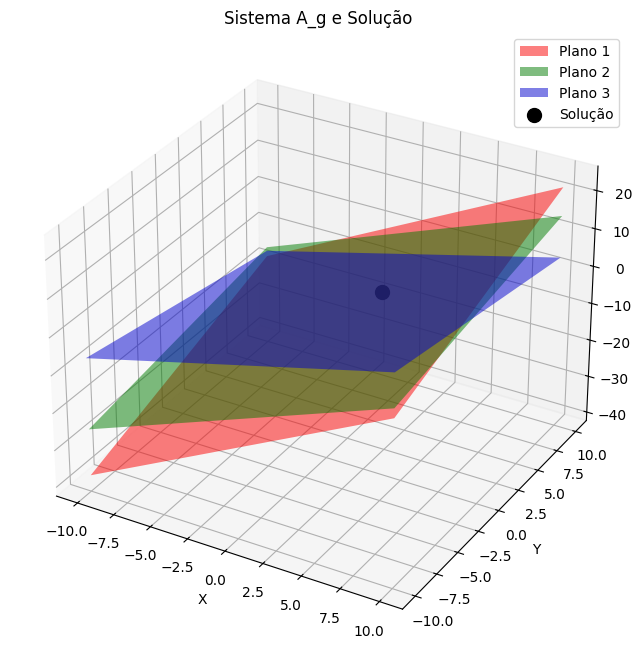


Visualizando o sistema de A_initial:


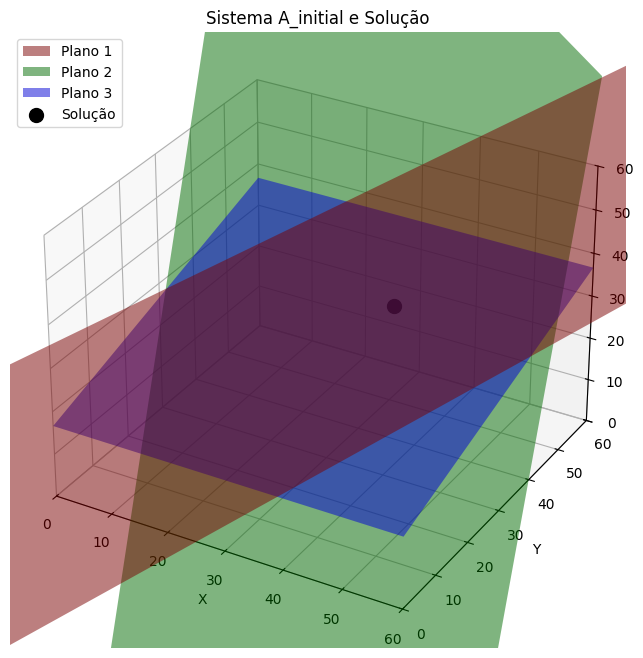

In [22]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_system_as_planes(A, b, solution=None, title='Sistema de Equações como Planos 3D'):
    """Plota um sistema de 3 equações lineares como planos em 3D.
    Args:
        A (np.array): Matriz de coeficientes (3x3).
        b (np.array): Vetor de termos independentes (3,).
        solution (np.array, optional): O vetor solução [x, y, z]. Se fornecido, o ponto será plotado.
        title (str, optional): Título do gráfico.
    """
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Cria uma grade para x e y
    x_vals = np.linspace(-10, 10, 100) # Ajuste o range conforme necessário para a sua solução
    y_vals = np.linspace(-10, 10, 100)
    X, Y = np.meshgrid(x_vals, y_vals)

    colors = ['r', 'g', 'b'] # Cores diferentes para cada plano

    for i in range(A.shape[0]):
        # Equação do plano: A[i,0]*x + A[i,1]*y + A[i,2]*z = b[i]
        # Precisamos de A[i,2] != 0 para resolver para z
        if abs(A[i, 2]) > 1e-9: # Verifica se o coeficiente de z não é zero
            Z = (b[i] - A[i, 0] * X - A[i, 1] * Y) / A[i, 2]
            ax.plot_surface(X, Y, Z, alpha=0.5, rstride=100, cstride=100, color=colors[i], label=f'Plano {i+1}')
        else:
            # Trata casos onde o coeficiente de z é zero (plano paralelo ao eixo z)
            print(f"Aviso: Coeficiente de z na equação {i+1} é zero. Pode não ser plotado corretamente.")

    # Plota a solução se fornecida
    if solution is not None:
        ax.scatter(solution[0], solution[1], solution[2], color='k', marker='o', s=100, label='Solução')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)
    ax.legend()
    plt.show()

# Exemplo de uso para a matriz A_g e sua solução
print("Visualizando o sistema de A_g:")
# A_g = np.array([[2.,1.,-1.],[-3.,-1.,2.],[-2.,1.,2.]])
# b_g = np.array([8.,-11.,-3.])
# x_g = np.array([2.,3.,-1.]) # Solução calculada anteriormente

plot_system_as_planes(A_g, b_g, solution=x_g, title='Sistema A_g e Solução')

# Exemplo de uso para a matriz A (do problema inicial) e sua solução
print("\nVisualizando o sistema de A_initial:")
# A_initial = np.array([[4., -1.,  0.],[-1.,  4., -1.],[0., -1.,  3.]])
# b_initial = np.array([100., 100., 50.])
# x_num = np.array([35.365854, 41.463415, 30.487805]) # Solução calculada anteriormente

# Ajustar os limites para a visualização, pois os valores da solução são maiores
# A função plot_system_as_planes precisa de ajustes nos linspace ou tratamento de coeficientes zero (como no terceiro plano de A_initial)

def plot_system_as_planes_adjusted(A, b, solution=None, title='Sistema de Equações como Planos 3D', x_range=(-50, 50), y_range=(-50, 50), z_range=(-50, 50)):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    x_vals = np.linspace(x_range[0], x_range[1], 100)
    y_vals = np.linspace(y_range[0], y_range[1], 100)
    X, Y = np.meshgrid(x_vals, y_vals)

    colors = ['r', 'g', 'b']

    for i in range(A.shape[0]):
        if abs(A[i, 2]) > 1e-9:
            Z = (b[i] - A[i, 0] * X - A[i, 1] * Y) / A[i, 2]
            ax.plot_surface(X, Y, Z, alpha=0.5, rstride=100, cstride=100, color=colors[i], label=f'Plano {i+1}')
        elif abs(A[i, 1]) > 1e-9: # Se z=0, tenta resolver para y
            Y_plane = (b[i] - A[i, 0] * X) / A[i, 1]
            ax.plot_surface(X, Y_plane, Y, alpha=0.5, rstride=100, cstride=100, color=colors[i], label=f'Plano {i+1}', linewidth=0)
        elif abs(A[i, 0]) > 1e-9: # Se y=0 e z=0, tenta resolver para x
            X_plane = (b[i]) / A[i, 0]
            ax.plot_surface(X_plane, X, Y, alpha=0.5, rstride=100, cstride=100, color=colors[i], label=f'Plano {i+1}', linewidth=0)
        else:
            print(f"Aviso: Equação {i+1} não é um plano válido para plotagem simples.")

    if solution is not None:
        ax.scatter(solution[0], solution[1], solution[2], color='k', marker='o', s=100, label='Solução')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)
    ax.legend()
    ax.set_xlim(x_range)
    ax.set_ylim(y_range)
    ax.set_zlim(z_range)
    plt.show()

plot_system_as_planes_adjusted(A_initial, b_initial, solution=x_num, title='Sistema A_initial e Solução',
                               x_range=(0, 60), y_range=(0, 60), z_range=(0, 60))


### 13.1 Geração de GIF para a Interseção dos Planos

Vamos criar uma função que gera um GIF mostrando os planos sendo adicionados um a um, culminando na visualização da solução como o ponto de interseção.

In [24]:
def plot_system_as_planes_gif(A, b, solution=None, gif_name='planes_intersection.gif',
                            title='Interseção dos Planos em 3D', x_range=(-10, 10), y_range=(-10, 10), z_range=(-10, 10),
                            rotation_steps=30, rotation_delay=0.1):
    """Gera um GIF mostrando planos 3D sendo adicionados e sua intersecção, com rotação final."""
    frames = []
    frame_count = 0

    x_vals = np.linspace(x_range[0], x_range[1], 100)
    y_vals = np.linspace(y_range[0], y_range[1], 100)
    X, Y = np.meshgrid(x_vals, y_vals)

    colors = ['r', 'g', 'b'] # Cores diferentes para cada plano

    # Gera frames para cada plano sendo adicionado
    for i in range(A.shape[0]):
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')

        # Plota os planos até o 'i'-ésimo plano
        for j in range(i + 1):
            if abs(A[j, 2]) > 1e-9:
                Z = (b[j] - A[j, 0] * X - A[j, 1] * Y) / A[j, 2]
                ax.plot_surface(X, Y, Z, alpha=0.5, rstride=100, cstride=100, color=colors[j], label=f'Plano {j+1}')
            elif abs(A[j, 1]) > 1e-9:
                Y_plane = (b[j] - A[j, 0] * X) / A[j, 1]
                ax.plot_surface(X, Y_plane, Y, alpha=0.5, rstride=100, cstride=100, color=colors[j], label=f'Plano {j+1}', linewidth=0)
            elif abs(A[j, 0]) > 1e-9:
                X_plane = (b[j]) / A[j, 0]
                ax.plot_surface(X_plane, X, Y, alpha=0.5, rstride=100, cstride=100, color=colors[j], label=f'Plano {j+1}', linewidth=0)

        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title(f'{title} - {i+1} Plano(s)')
        ax.legend()
        ax.set_xlim(x_range)
        ax.set_ylim(y_range)
        ax.set_zlim(z_range)

        filename = f'plane_step_{frame_count:02d}.png'
        fig.tight_layout()
        plt.savefig(filename, dpi=100)
        plt.close(fig)
        frames.append(filename)
        frame_count += 1

    # Gera frames para a rotação, se a solução for fornecida
    if solution is not None:
        for angle in range(0, 360, 360 // rotation_steps):
            fig = plt.figure(figsize=(10, 8))
            ax = fig.add_subplot(111, projection='3d')

            for j in range(A.shape[0]):
                if abs(A[j, 2]) > 1e-9:
                    Z = (b[j] - A[j, 0] * X - A[j, 1] * Y) / A[j, 2]
                    ax.plot_surface(X, Y, Z, alpha=0.5, rstride=100, cstride=100, color=colors[j], label=f'Plano {j+1}')
                elif abs(A[j, 1]) > 1e-9:
                    Y_plane = (b[j] - A[j, 0] * X) / A[j, 1]
                    ax.plot_surface(X, Y_plane, Y, alpha=0.5, rstride=100, cstride=100, color=colors[j], label=f'Plano {j+1}', linewidth=0)
                elif abs(A[j, 0]) > 1e-9:
                    X_plane = (b[j]) / A[j, 0]
                    ax.plot_surface(X_plane, X, Y, alpha=0.5, rstride=100, cstride=100, color=colors[j], label=f'Plano {j+1}', linewidth=0)

            ax.scatter(solution[0], solution[1], solution[2], color='k', marker='o', s=100, label='Solução', depthshade=True)
            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            ax.set_zlabel('Z')
            ax.set_title(f'{title} - Com Solução (Vista Rotacionada)')
            ax.legend()
            ax.set_xlim(x_range)
            ax.set_ylim(y_range)
            ax.set_zlim(z_range)

            ax.view_init(elev=20, azim=angle) # Rotação aqui!

            filename = f'plane_step_{frame_count:02d}.png'
            fig.tight_layout()
            plt.savefig(filename, dpi=100)
            plt.close(fig)
            frames.append(filename)
            frame_count += 1

    create_gif(frames, gif_name, duration=rotation_delay)

# Exemplo de uso para a matriz A_g e sua solução
print("Gerando GIF de intersecção de planos para A_g (com rotação)...")
plot_system_as_planes_gif(A_g, b_g, solution=x_g, gif_name='gauss_planes_intersection_rotated.gif',
                          title='Interseção dos Planos (Exemplo Gauss)', x_range=(0, 4), y_range=(1, 5), z_range=(-3, 1),
                          rotation_steps=45, rotation_delay=0.1)

# Exemplo de uso para a matriz A_initial e sua solução
print("\nGerando GIF de intersecção de planos para A_initial (com rotação)...")
plot_system_as_planes_gif(A_initial, b_initial, solution=x_num, gif_name='initial_planes_intersection_rotated.gif',
                          title='Interseção dos Planos (Problema Inicial)', x_range=(20, 50), y_range=(20, 50), z_range=(20, 50),
                          rotation_steps=45, rotation_delay=0.1)

Gerando GIF de intersecção de planos para A_g (com rotação)...
GIF salvo como gauss_planes_intersection_rotated.gif

Gerando GIF de intersecção de planos para A_initial (com rotação)...
GIF salvo como initial_planes_intersection_rotated.gif


In [21]:
def doolittle_com_gif(A, gif_name='lu_decomposition.gif', tol=1e-12):
    """Fatoração LU com geração de GIF para visualizar as etapas."""
    A_copy = np.asarray(A, dtype=float, copy=True)
    n = A_copy.shape[0]
    if A_copy.shape != (n, n): raise ValueError("A deve ser quadrada")
    L_gif = np.eye(n)
    U_gif = np.zeros_like(A_copy)

    frames = []
    frame_count = 0

    # Frame inicial: Matriz A original
    filename = f'lu_step_{frame_count:02d}.png'
    plot_matrix_state(A_copy, f'LU: Matriz A Original', filename, show_grid=True)
    frames.append(filename)
    frame_count += 1

    for k in range(n):
        # Calcula a linha k de U
        for j in range(k, n):
            U_gif[k, j] = A_copy[k, j] - L_gif[k, :k] @ U_gif[:k, j]

        # Plota o estado após calcular uma linha de U
        filename = f'lu_step_{frame_count:02d}.png'
        plot_matrix_state(U_gif, f'LU: U após linha {k+1}', filename, show_grid=True)
        frames.append(filename)
        frame_count += 1

        if abs(U_gif[k, k]) < tol:
            raise np.linalg.LinAlgError("Pivô nulo; pode ser necessário pivotear")

        # Calcula a coluna k de L abaixo da diagonal
        for i in range(k + 1, n):
            L_gif[i, k] = (A_copy[i, k] - L_gif[i, :k] @ U_gif[:k, k]) / U_gif[k, k]

        # Plota o estado após calcular uma coluna de L
        filename = f'lu_step_{frame_count:02d}.png'
        plot_matrix_state(L_gif, f'LU: L após coluna {k+1}', filename, show_grid=True)
        frames.append(filename)
        frame_count += 1

    # Frames finais com L e U completas
    filename = f'lu_step_{frame_count:02d}.png'
    plot_matrix_state(L_gif, f'LU: Matriz L Final', filename, show_grid=True)
    frames.append(filename)
    frame_count += 1

    filename = f'lu_step_{frame_count:02d}.png'
    plot_matrix_state(U_gif, f'LU: Matriz U Final', filename, show_grid=True)
    frames.append(filename)
    frame_count += 1

    create_gif(frames, gif_name)

    return L_gif, U_gif

# Exemplo de uso com a matriz A_lu do notebook
print("Gerando GIF para Decomposição LU...")
L_lu_gif, U_lu_gif = doolittle_com_gif(A_lu, gif_name='lu_A_lu.gif')
print("L final (LU):\n", L_lu_gif)
print("U final (LU):\n", U_lu_gif)

# Exemplo com uma nova matriz 2x2
print("\nGerando GIF para Decomposição LU (nova matriz 2x2)...")
A_new_2x2 = np.array([[3., 1.],
                        [6., 4.]])
L_new_2x2_gif, U_new_2x2_gif = doolittle_com_gif(A_new_2x2, gif_name='lu_A_new_2x2.gif')
print("L final (Nova 2x2):\n", L_new_2x2_gif)
print("U final (Nova 2x2):\n", U_new_2x2_gif)


Gerando GIF para Decomposição LU...
GIF salvo como lu_A_lu.gif
L final (LU):
 [[ 1.        0.        0.      ]
 [ 2.        1.        0.      ]
 [-1.        0.333333  1.      ]]
U final (LU):
 [[ 2. -1.  1.]
 [ 0.  3. -3.]
 [ 0.  0.  5.]]

Gerando GIF para Decomposição LU (nova matriz 2x2)...
GIF salvo como lu_A_new_2x2.gif
L final (Nova 2x2):
 [[1. 0.]
 [2. 1.]]
U final (Nova 2x2):
 [[3. 1.]
 [0. 2.]]
